## Continuous Random Variables

So far all our examples have been discrete — a finite (or countably infinite) list of possible values. Now let's talk about **continuous** random variables, where the outcome can be any value in a range.

Here's the key shift in thinking: with a continuous variable, there are infinitely many possible values. The probability of landing on any *exact* value is essentially zero. You'll never measure someone's height as exactly 170.0000000... cm.

Instead, we ask about **ranges**: what's the probability that height is between 165 and 175 cm? What's the probability that a measurement falls within one standard deviation of the mean?

This means we can't use a PMF (which assigns probability to individual points). Instead, we need a different tool: the **Probability Density Function**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# Fix the random seed so results are reproducible
rng = np.random.default_rng(42)

# Nice plot defaults
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

In [2]:
def plot_uniform(
    a=widgets.FloatSlider(min=-10.0, max=9.9, step=0.1, value=0.0, continuous_update=False, description='a'),
    b=widgets.FloatSlider(min=-9.9, max=10.0, step=0.1, value=1.0, continuous_update=False, description='b')
):
    # Ensure b > a
    if b <= a:
        b = a + 0.1
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.linspace(a - 0.5, b + 0.5, 500)
    pdf_u = stats.uniform.pdf(x, loc=a, scale=b - a)
    ax.plot(x, pdf_u, color='mediumpurple', linewidth=2.5)
    ax.fill_between(x, pdf_u, alpha=0.2, color='mediumpurple')
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Uniform Distribution (a={a:.1f}, b={b:.1f})')
    height = 1 / (b - a)
    ax.text((a + b) / 2, height * 1.1, f'density = {height:.3f}', ha='center', fontsize=10)
    ax.set_ylim(0, height * 1.5)
    plt.tight_layout()
    plt.show()

interact(plot_uniform)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='a', max=9.9, min=-10.0), Fl…

<function __main__.plot_uniform(a=FloatSlider(value=0.0, continuous_update=False, description='a', max=9.9, min=-10.0), b=FloatSlider(value=1.0, continuous_update=False, description='b', max=10.0, min=-9.9))>

---
## 10. Probability Density Function (PDF)

The **Probability Density Function** (PDF) is the continuous analog of the PMF. Instead of giving you the probability at each point, it gives you a curve where:

- The **area under the entire curve** equals 1 (something has to happen)
- The **area under the curve between two values a and b** equals the probability of the variable landing in that range

A higher curve at some point means values there are more probable, but the probability of any exact point is still zero — it's all about area.

Think of it like this: a PMF has bars with heights that are probabilities. A PDF has a smooth curve, and the probabilities live in the area *under* that curve, not in the height of the curve at a single point.

In [3]:
def plot_normal(
    mu=widgets.FloatSlider(min=-5.0, max=5.0, step=0.1, value=0.0, continuous_update=False, description='mu'),
    sigma=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, continuous_update=False, description='sigma')
):
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
    pdf_n = stats.norm.pdf(x, loc=mu, scale=sigma)
    ax.plot(x, pdf_n, color='steelblue', linewidth=2.5)
    ax.fill_between(x, pdf_n, alpha=0.2, color='steelblue')
    ax.axvline(x=mu, color='red', linestyle='--', linewidth=2, label=f'Mean = {mu:.1f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Normal Distribution (mu={mu:.1f}, sigma={sigma:.1f})')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

interact(plot_normal)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='mu', max=5.0, min=-5.0), Fl…

<function __main__.plot_normal(mu=FloatSlider(value=0.0, continuous_update=False, description='mu', max=5.0, min=-5.0), sigma=FloatSlider(value=1.0, continuous_update=False, description='sigma', max=5.0, min=0.1))>

---
## 11. Common Continuous Distributions

Just like with discrete distributions, certain shapes come up so often that we've given them names. Let's look at three of the most important ones.

### Uniform Distribution

The simplest continuous distribution: every value in a range [a, b] is equally likely. The PDF is flat — a horizontal line.

Example: if a bus arrives at a random time in a 10-minute window, any minute is equally likely. Your waiting time is Uniform(0, 10).

You see this a lot in simulation and as a building block for generating other distributions.

### Standard Normal Distribution and Z-scores

Any Normal distribution can be converted to the **standard Normal** — which has mean 0 and standard deviation 1 — by subtracting the mean and dividing by the standard deviation. The result is called a **Z-score**.

A Z-score tells you how many standard deviations above or below the mean a value sits. A Z-score of 0 means the value is exactly at the mean. A Z-score of +2 means the value is 2 standard deviations above the mean. A Z-score of -1 means one standard deviation below.

Why does this matter? Because once you convert to Z-scores, you can look up probabilities using a single standard table (or a single scipy function), regardless of what the original mean and standard deviation were. You do not need a separate table for every possible Normal distribution.

Example: shoe sizes are normally distributed with a mean of 10 and a standard deviation of 1. A size 12 shoe has a Z-score of (12 - 10) / 1 = 2. That means size 12 is 2 standard deviations above average, and we can immediately say about 97.5% of people wear a smaller size.

In [4]:
def plot_exponential(rate=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, continuous_update=False, description='rate')):
    fig, ax = plt.subplots(figsize=(8, 4))
    mean_time = 1 / rate
    x = np.linspace(0, 6 * mean_time, 500)
    pdf_e = stats.expon.pdf(x, scale=mean_time)
    ax.plot(x, pdf_e, color='darkorange', linewidth=2.5)
    ax.fill_between(x, pdf_e, alpha=0.2, color='darkorange')
    ax.axvline(x=mean_time, color='navy', linestyle='--', linewidth=2, label=f'Mean = {mean_time:.2f}')
    ax.set_xlabel('Time Until Next Event')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Exponential Distribution (rate={rate:.1f})')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

interact(plot_exponential)

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='rate', max=5.0, min=0.1), O…

<function __main__.plot_exponential(rate=FloatSlider(value=1.0, continuous_update=False, description='rate', max=5.0, min=0.1))>

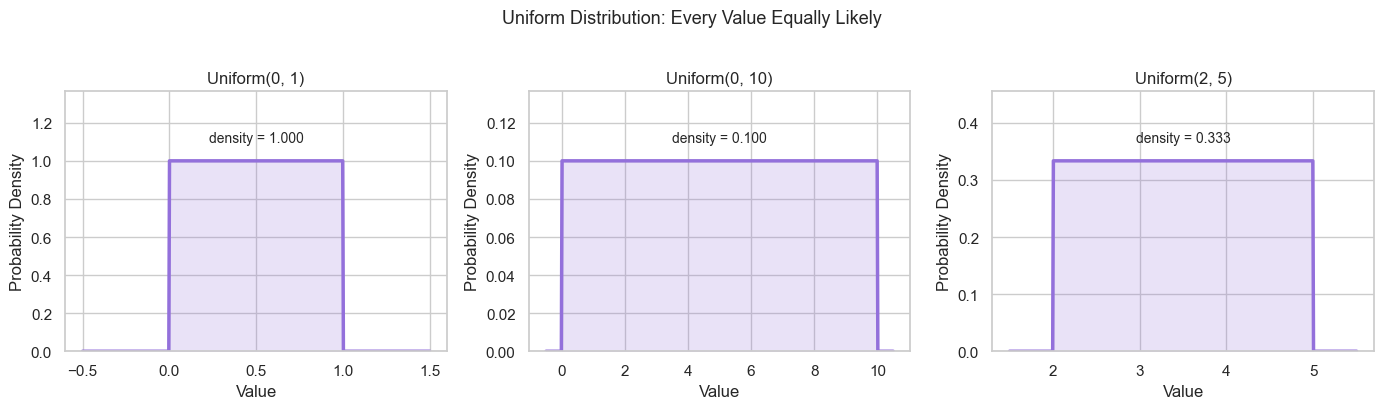

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

uniform_params = [(0, 1), (0, 10), (2, 5)]
for ax, (a, b) in zip(axes, uniform_params):
    x = np.linspace(a - 0.5, b + 0.5, 500)
    pdf_u = stats.uniform.pdf(x, loc=a, scale=b - a)
    ax.plot(x, pdf_u, color='mediumpurple', linewidth=2.5)
    ax.fill_between(x, pdf_u, alpha=0.2, color='mediumpurple')
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Uniform({a}, {b})')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
    height = 1 / (b - a)
    ax.text((a + b) / 2, height * 1.1, f'density = {height:.3f}', ha='center', fontsize=10)

plt.suptitle('Uniform Distribution: Every Value Equally Likely', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Normal (Gaussian) Distribution

The **Normal distribution** is the famous bell curve. It comes up everywhere — heights, measurement errors, test scores, financial returns, and (crucially for us) the behavior of many machine learning estimators.

Two parameters fully describe it:
- **Mean** (often called mu): where the center of the bell is
- **Standard deviation** (often called sigma): how wide the bell is. A small standard deviation gives a tall, narrow bell; a large one gives a short, wide bell.

Why does it appear so often? The **Central Limit Theorem** says that whenever you add up many independent random influences, the result tends to be normally distributed — regardless of what distribution the individual influences follow. Almost any measurement in nature is the sum of many tiny factors, which is why the normal distribution fits so well.

A useful rule of thumb:
- About 68% of values fall within 1 standard deviation of the mean
- About 95% fall within 2 standard deviations
- About 99.7% fall within 3 standard deviations

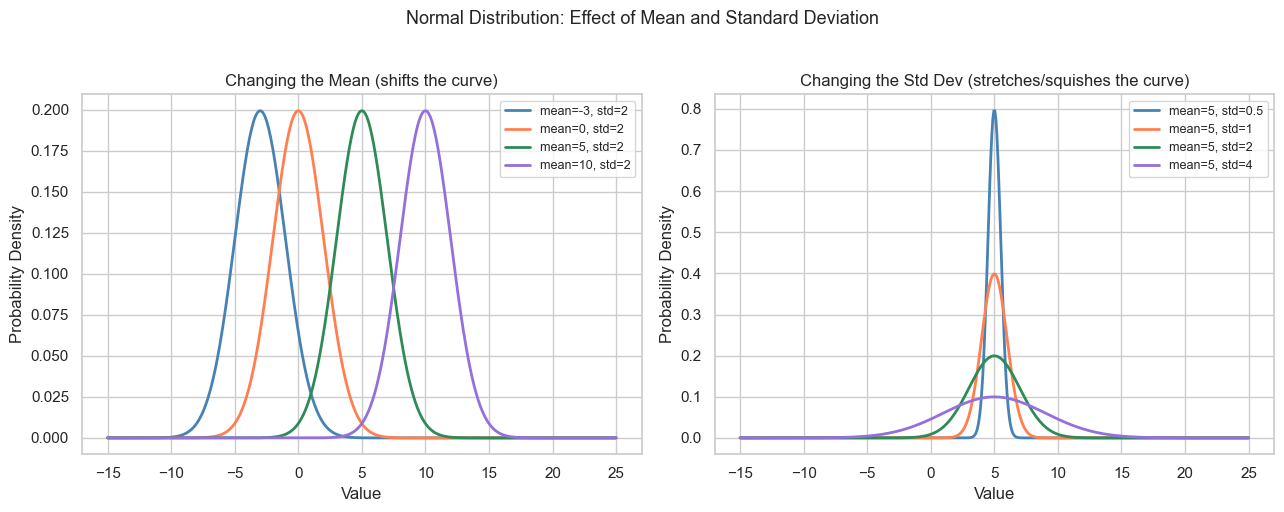

In [7]:
# Show how changing mean and std dev reshapes the normal distribution
x = np.linspace(-15, 25, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: vary the mean, keep std dev fixed
for mean, color in zip([-3, 0, 5, 10], ['steelblue', 'coral', 'seagreen', 'mediumpurple']):
    pdf_n = stats.norm.pdf(x, loc=mean, scale=2)
    axes[0].plot(x, pdf_n, linewidth=2, color=color, label=f'mean={mean}, std=2')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Changing the Mean (shifts the curve)')
axes[0].legend(fontsize=9)

# Right: keep mean fixed, vary std dev
for std, color in zip([0.5, 1, 2, 4], ['steelblue', 'coral', 'seagreen', 'mediumpurple']):
    pdf_n = stats.norm.pdf(x, loc=5, scale=std)
    axes[1].plot(x, pdf_n, linewidth=2, color=color, label=f'mean=5, std={std}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('Changing the Std Dev (stretches/squishes the curve)')
axes[1].legend(fontsize=9)

plt.suptitle('Normal Distribution: Effect of Mean and Standard Deviation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

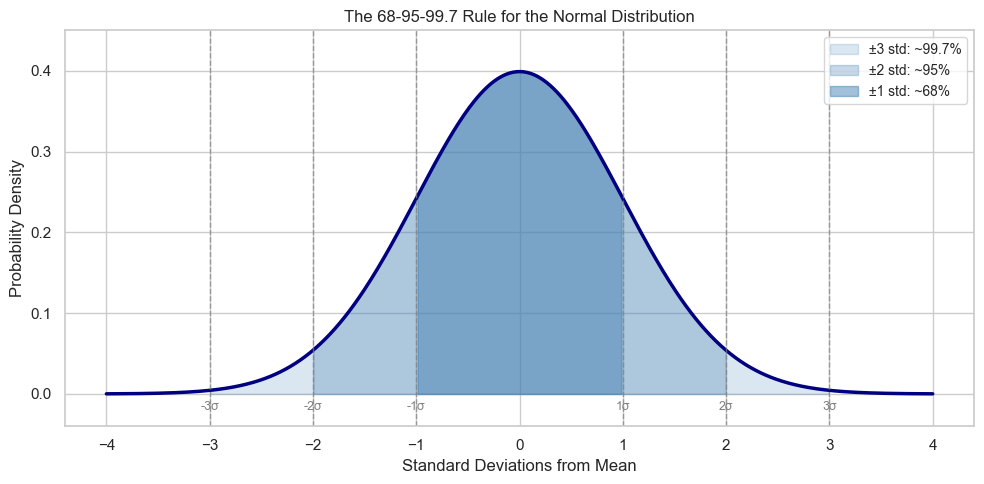

Exact probabilities within 1, 2, 3 standard deviations:
  ±1 std: 0.6827 (68.27%)
  ±2 std: 0.9545 (95.45%)
  ±3 std: 0.9973 (99.73%)


In [8]:
# Illustrate the 68-95-99.7 rule
x = np.linspace(-4, 4, 500)
pdf_std = stats.norm.pdf(x, 0, 1)

fig, ax = plt.subplots(figsize=(10, 5))

# 3 standard deviations (99.7%)
mask3 = (x >= -3) & (x <= 3)
ax.fill_between(x, pdf_std, where=mask3, alpha=0.2, color='steelblue', label='±3 std: ~99.7%')

# 2 standard deviations (95%)
mask2 = (x >= -2) & (x <= 2)
ax.fill_between(x, pdf_std, where=mask2, alpha=0.3, color='steelblue', label='±2 std: ~95%')

# 1 standard deviation (68%)
mask1 = (x >= -1) & (x <= 1)
ax.fill_between(x, pdf_std, where=mask1, alpha=0.5, color='steelblue', label='±1 std: ~68%')

ax.plot(x, pdf_std, color='navy', linewidth=2.5)

# Mark the standard deviation boundaries
for std_val in [-3, -2, -1, 1, 2, 3]:
    ax.axvline(std_val, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(std_val, -0.02, f'{std_val}σ', ha='center', fontsize=9, color='gray')

ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Probability Density')
ax.set_title('The 68-95-99.7 Rule for the Normal Distribution')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(-0.04, 0.45)

plt.tight_layout()
plt.show()

# Verify with scipy
p1 = stats.norm.cdf(1) - stats.norm.cdf(-1)
p2 = stats.norm.cdf(2) - stats.norm.cdf(-2)
p3 = stats.norm.cdf(3) - stats.norm.cdf(-3)
print(f"Exact probabilities within 1, 2, 3 standard deviations:")
print(f"  ±1 std: {p1:.4f} ({p1*100:.2f}%)")
print(f"  ±2 std: {p2:.4f} ({p2*100:.2f}%)")
print(f"  ±3 std: {p3:.4f} ({p3*100:.2f}%)")

### Exponential Distribution

Recall the **Poisson distribution**: it counts how many events happen in a fixed time window (e.g., how many customers arrive in an hour).

The **Exponential distribution** is its continuous counterpart: it models the *time between* events in a Poisson process. If customers arrive at an average rate of 5 per hour, how long do you wait until the next one?

The parameter is usually called the **rate** (events per unit time). The mean waiting time is 1 / rate.

It has a clean physical interpretation: it's **memoryless**. If you've already waited 10 minutes for a bus, your expected remaining wait time is the same as if you had just arrived at the stop. The distribution doesn't remember how long you've been waiting.

This is also related to the **Geometric distribution** we saw earlier — Geometric is the discrete version (number of coin flips until heads), and Exponential is the continuous version (time until the next event).

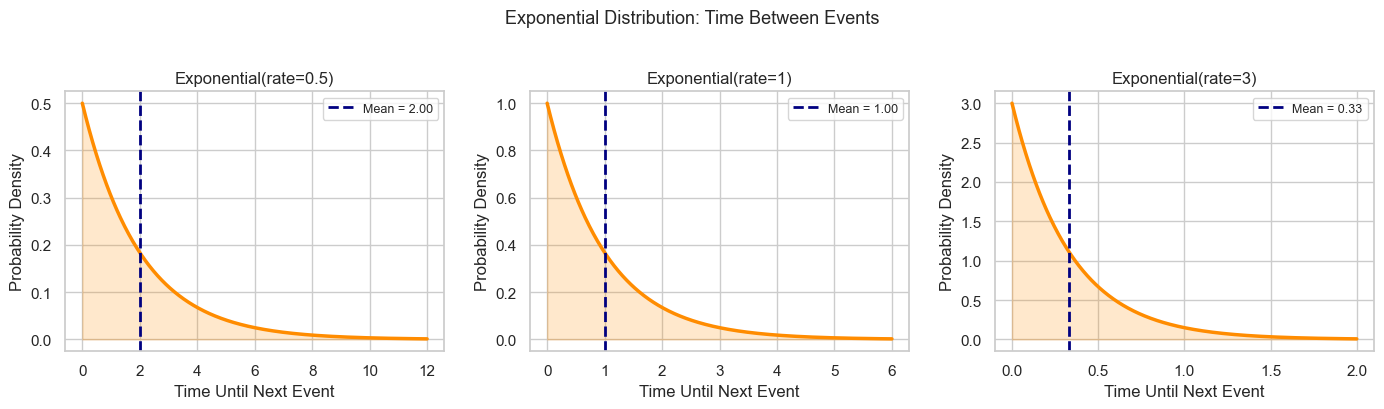

Higher rate = events happen more often = shorter wait times = curve drops off faster.
The distribution is always highest at 0: the next event could happen immediately.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# scipy's expon uses scale = 1/rate (the mean)
rates = [0.5, 1, 3]  # events per unit time
for ax, rate in zip(axes, rates):
    mean_time = 1 / rate
    x = np.linspace(0, 6 * mean_time, 500)
    pdf_e = stats.expon.pdf(x, scale=mean_time)
    ax.plot(x, pdf_e, color='darkorange', linewidth=2.5)
    ax.fill_between(x, pdf_e, alpha=0.2, color='darkorange')
    ax.axvline(mean_time, color='navy', linestyle='--', linewidth=2,
               label=f'Mean = {mean_time:.2f}')
    ax.set_xlabel('Time Until Next Event')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Exponential(rate={rate})')
    ax.legend(fontsize=9)

plt.suptitle('Exponential Distribution: Time Between Events', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Higher rate = events happen more often = shorter wait times = curve drops off faster.")
print("The distribution is always highest at 0: the next event could happen immediately.")

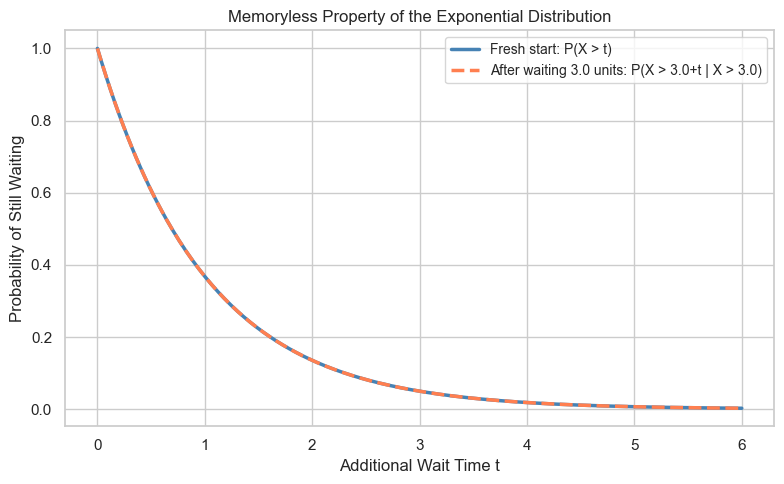

The two curves are identical!
Having already waited 3.0 units tells you nothing about how much longer you'll wait.
The distribution is memoryless.


In [10]:
# Demonstrate the memoryless property
# If X ~ Exponential(rate=1), then P(X > s+t | X > s) = P(X > t)
# In other words: given you've already waited s minutes, the remaining wait
# has the same distribution as if you had just started waiting.

rate = 1.0
s = 3.0  # already waited 3 units

# P(X > t) for a fresh start
t_values = np.linspace(0, 6, 300)
p_fresh = stats.expon.sf(t_values, scale=1/rate)  # sf = survival function = P(X > t)

# P(X > s+t | X > s) = P(X > s+t) / P(X > s) -- conditional probability
p_conditional = stats.expon.sf(s + t_values, scale=1/rate) / stats.expon.sf(s, scale=1/rate)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_values, p_fresh, color='steelblue', linewidth=2.5, label='Fresh start: P(X > t)')
ax.plot(t_values, p_conditional, color='coral', linewidth=2.5, linestyle='--',
        label=f'After waiting {s} units: P(X > {s}+t | X > {s})')
ax.set_xlabel('Additional Wait Time t')
ax.set_ylabel('Probability of Still Waiting')
ax.set_title('Memoryless Property of the Exponential Distribution')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("The two curves are identical!")
print(f"Having already waited {s} units tells you nothing about how much longer you'll wait.")
print("The distribution is memoryless.")

## Gamma Distribution

As the **exponential distribution** models the time to wait for the _first_ event in a time series, the **gamma distribution** models the time to wait for the _rth event_ in a time series. 

In fact, you can think of the exponential and gamma distributions as the continuous equivalent of the geometric and negative binomial distributions.

In [6]:
def plot_gamma(
    r=widgets.IntSlider(min=1, max=20, step=1, value=3, continuous_update=False, description='r (events)'),
    rate=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, continuous_update=False, description='rate')
):
    fig, ax = plt.subplots(figsize=(8, 4))
    # scipy gamma: a=r (shape), scale=1/rate
    mean_val = r / rate
    x_max = stats.gamma.ppf(0.999, a=r, scale=1/rate)
    x = np.linspace(0, x_max, 500)
    pdf_g = stats.gamma.pdf(x, a=r, scale=1/rate)
    ax.plot(x, pdf_g, color='saddlebrown', linewidth=2.5)
    ax.fill_between(x, pdf_g, alpha=0.2, color='saddlebrown')
    ax.axvline(x=mean_val, color='navy', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.set_xlabel('Time Until r-th Event')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Gamma Distribution (r={r}, rate={rate:.1f})')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

interact(plot_gamma)

interactive(children=(IntSlider(value=3, continuous_update=False, description='r (events)', max=20, min=1), Fl…

<function __main__.plot_gamma(r=IntSlider(value=3, continuous_update=False, description='r (events)', max=20, min=1), rate=FloatSlider(value=1.0, continuous_update=False, description='rate', max=5.0, min=0.1))>